# Stuttering Detection: Support Vector Machine (SVM) Analysis
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
---

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import DataManager
from src.models import LinearSVMModel, KernelSVMModel
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import PCA
import joblib

# ==========================================
# CONFIGURATION
# ==========================================
SAMPLE_LIMIT = None
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
RANDOM_SEED = 42
FEATURE_DIR = "data/features"
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips"  # Path to raw audio
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]

## Step 1: Data Loading & Preparation
Using Strict High-Agreement Labels.

In [2]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

X, y = manager.load_from_folders(
    os.path.join(FEATURE_DIR, "fluent"), 
    os.path.join(FEATURE_DIR, "disfluent"), 
    limit=SAMPLE_LIMIT, 
    label_dict=label_dict
)

X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# PREPROCESS (Fit on train, transform on val/test)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, method="standard", fit=False)
X_test_final = manager.preprocess(X_test, method="standard", fit=False)

print(f"Data Loaded: {len(X)} samples.")
manager.analyze_distribution()

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
Data Loaded: 14452 samples.
--- Data Distribution ---
Fluent (0): 7784 (53.9%)
Disfluent (1): 6668 (46.1%)
Total: 14452


## Step 2: SVM Baselines

In [3]:
lin_svm = LinearSVMModel("Linear_SVM_Baseline")
lin_svm.train(X_train_final, y_train_bal)
print("Evaluating Linear SVM Baseline:")
lin_svm.evaluate(X_test_final, y_test)

rbf_svm = KernelSVMModel("RBF_SVM_Baseline", kernel="rbf")
rbf_svm.train(X_train_final, y_train_bal)
print("Evaluating RBF SVM Baseline:")
rbf_svm.evaluate(X_test_final, y_test)

[Model: Linear_SVM_Baseline] Initialized.
[Linear_SVM_Baseline] Training with Linear Margin (C=1.0)...
Evaluating Linear SVM Baseline:

--- Evaluation: Linear_SVM_Baseline ---
Accuracy: 0.8072
Precision: 0.8057
Recall: 0.7670
F1: 0.7859

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      983             185            
True: Stutter(1)     233             767            
[Model: RBF_SVM_Baseline] Initialized.
[RBF_SVM_Baseline] Training with RBF Kernel (C=1.0)...
Evaluating RBF SVM Baseline:

--- Evaluation: RBF_SVM_Baseline ---
Accuracy: 0.8150
Precision: 0.8339
Recall: 0.7480
F1: 0.7886

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      1019            149            
True: Stutter(1)     252             748            


{'accuracy': 0.8150369003690037,
 'precision': 0.8338907469342252,
 'recall': 0.748,
 'f1': 0.7886136004217185,
 'confusion_matrix': array([[1019,  149],
        [ 252,  748]])}

## Step 3: Expanded SVM Hypertuning
Broadening ranges and adding Polynomial kernel.

In [4]:
print("--- [STARTING EXPANDED SVM HYPERTUNING] ---")

# 1. Combine Train + Val and create split indices
X_combined = np.vstack((X_train_final, X_val_final))
y_combined = np.hstack((y_train_bal, y_val))
test_fold = np.hstack((
    np.full(len(X_train_final), -1),
    np.full(len(X_val_final), 0)
))
pds = PredefinedSplit(test_fold=test_fold)

# 2. Expanded Grid Search
svm_grid = [
    {   # RBF (The Standard)
        "C": [0.1, 1, 10, 100, 1000],
        "gamma": ["scale", "auto", 0.001, 0.01],
        "kernel": ["rbf"]
    },
    {   # Poly (Width & Curvature)
        "C": [0.1, 1, 10],
        "kernel": ["poly"],
        "degree": [2, 3],
        "coef0": [0.0, 1.0], # Helps shift the polynomial curves
        "gamma": ["scale"]
    },
    {   # Sigmoid (Neural-like)
        "C": [0.1, 1, 10],
        "kernel": ["sigmoid"],
        "coef0": [0.0, 1.0],
        "gamma": ["scale"]
    }
]

gs_svm = GridSearchCV(SVC(random_state=RANDOM_SEED), svm_grid, cv=pds, scoring="accuracy", n_jobs=-1, verbose=1)
gs_svm.fit(X_combined, y_combined)

# --- EXPERIMENTAL DATA EXPORT ---
# Convert the full study results into a DataFrame
results_df = pd.DataFrame(gs_svm.cv_results_)
# Sort by best accuracy for easy reading
results_df = results_df.sort_values(by='rank_test_score')
# Save to the reports folder
os.makedirs("reports", exist_ok=True)
results_df.to_csv("reports/svm_hypertuning_benchmarks.csv", index=False)
print(f"[System] Comprehensive trial results exported to: reports/svm_hypertuning_benchmarks.csv")
print(f"Total Trials Recorded: {len(results_df)}")

print(f"Best SVM Params: {gs_svm.best_params_}")
print(f"Best Val Accuracy: {gs_svm.best_score_:.4f}")

--- [STARTING EXPANDED SVM HYPERTUNING] ---
Fitting 1 folds for each of 38 candidates, totalling 38 fits
[System] Comprehensive trial results exported to: reports/svm_hypertuning_benchmarks.csv
Total Trials Recorded: 38
Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Val Accuracy: 0.8293


## Step 4: Visualizing Confusion Matrices

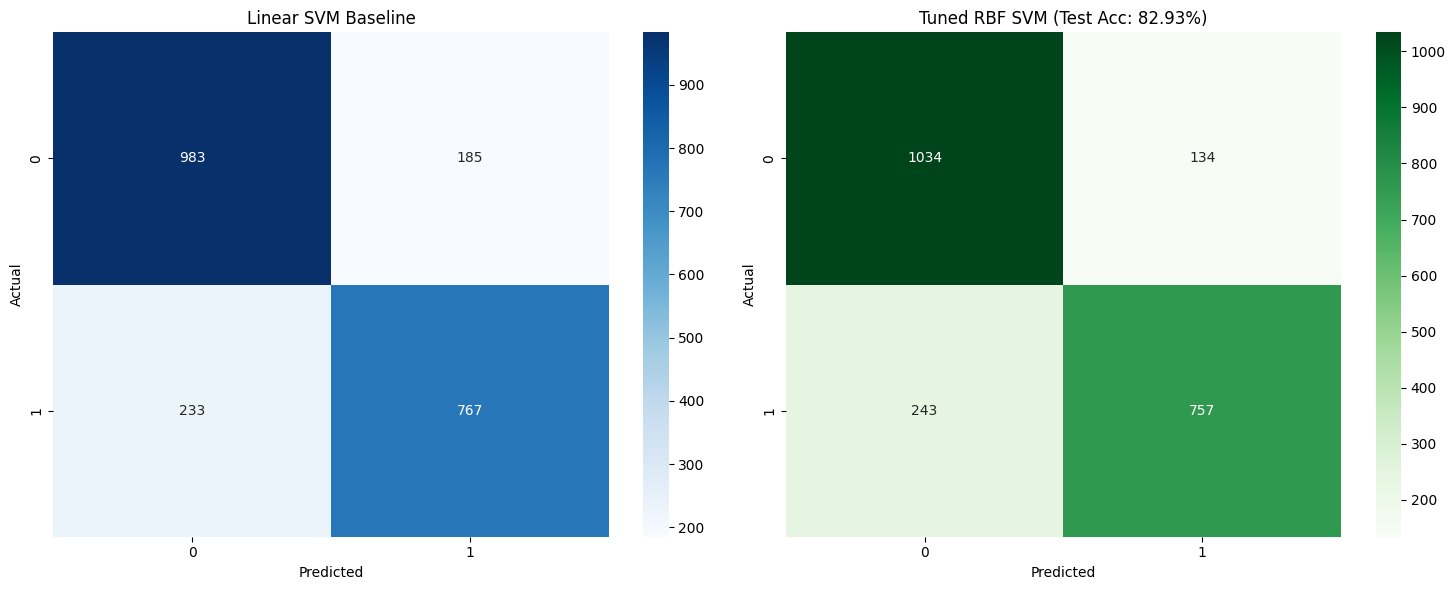

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Linear SVM CM
y_pred_lin = lin_svm.predict(X_test_final)
cm_lin = confusion_matrix(y_test, y_pred_lin)
sns.heatmap(cm_lin, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Linear SVM Baseline")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Tuned Kernel SVM CM
y_pred_tuned = gs_svm.best_estimator_.predict(X_test_final)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Tuned RBF SVM (Test Acc: {gs_svm.best_score_:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Step 5: Decision Boundary Visualization (PCA 2D)
Projecting 768 dimensions down to 2 for visual intuition.

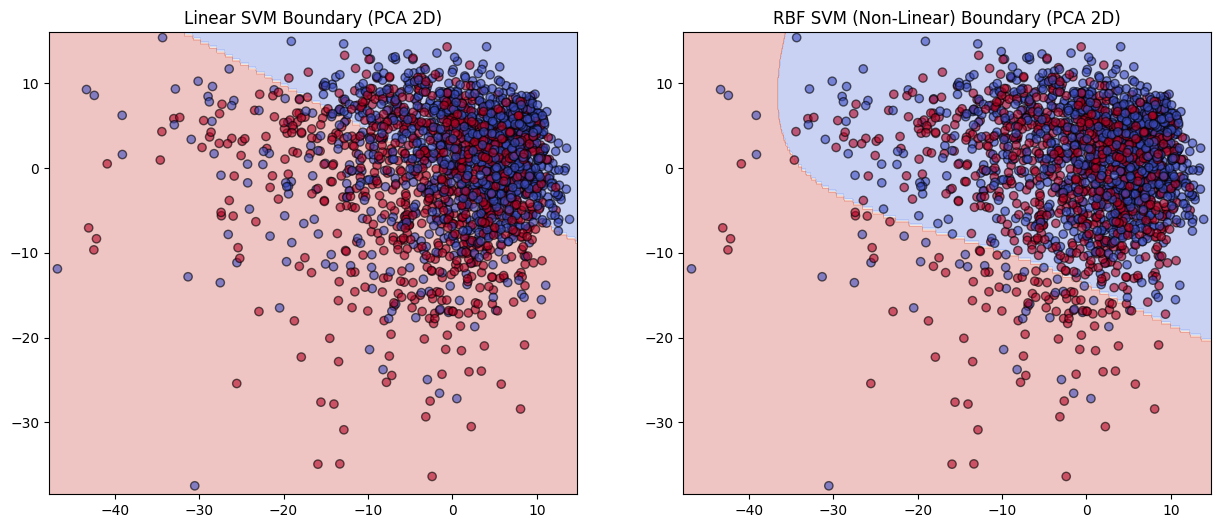

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_final)

# Create mesh grid with coarser step for faster plotting
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.5))

plt.figure(figsize=(15, 6))

# Subplot 1: Linear SVM
plt.subplot(1, 2, 1)
Z_lin = lin_svm.model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z_lin = Z_lin.reshape(xx.shape)
plt.contourf(xx, yy, Z_lin, alpha=0.3, cmap="coolwarm")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, edgecolors="k", cmap="coolwarm", alpha=0.6)
plt.title("Linear SVM Boundary (PCA 2D)")

# Subplot 2: Tuned RBF SVM
plt.subplot(1, 2, 2)
Z_rbf = gs_svm.best_estimator_.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z_rbf = Z_rbf.reshape(xx.shape)
plt.contourf(xx, yy, Z_rbf, alpha=0.3, cmap="coolwarm")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, edgecolors="k", cmap="coolwarm", alpha=0.6)
plt.title("RBF SVM (Non-Linear) Boundary (PCA 2D)")

plt.show()

## Step 6: Model Persistence

In [7]:
os.makedirs("models", exist_ok=True)
joblib.dump(gs_svm.best_estimator_, "models/svm_rbf_best.pkl")
print("[System] Best SVM model saved to disk.")

[System] Best SVM model saved to disk.


In [8]:
svm_final_accuracy = accuracy_score(y_test, y_pred_tuned)
svm_final_f1 = f1_score(y_test, y_pred_tuned)
print(f"[Benchmark] SVM Optimization Complete.")
print(f"Final Test Accuracy: {svm_final_accuracy:.4f}")
print(f"Final F1 Score: {svm_final_f1:.4f}")


[Benchmark] SVM Optimization Complete.
Final Test Accuracy: 0.8261
Final F1 Score: 0.8006
